<a href="https://colab.research.google.com/github/drizzletechnova/project-work-models/blob/main/three_tank_model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cascaded Three-Tank System — Surrogate NMPC (LSTM / GRU / Transformer)

Third case study in the dissertation pipeline: nonlinear 3-input/3-output
MIMO plant (cuboidal, trapezoidal, parabolic tanks in series).

Sections:
1. Setup & data loading
2. Dataset windowing
3. Surrogate architectures (LSTM / GRU / Transformer, non-autoregressive seq2seq)
4. Training + training-curve plots
5. Open-loop evaluation + prediction-vs-true plots
6. Python ground-truth plant (for closed-loop testing)
7. NMPC controller (SLSQP + PyTorch autograd)
8. Closed-loop results + plots
9. Architecture comparison (IAE/ISE)

**Before running:** upload the `.csv` files produced by `three_tank_datagen.m`
as a Kaggle dataset and attach it to this notebook (they'll appear under
`/kaggle/input/<dataset-name>/`). Update `DATA_DIR` in the cell below.


## 1. Setup

In [1]:
import os, glob, math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device being used:", device)

DATA_DIR = "/content"
OUT_DIR = "/content/checkpoints"
os.makedirs(OUT_DIR, exist_ok=True)

data = pd.read_csv("/content/three_tank_master_dataset.csv")


Device being used: cuda


In [2]:
data.head()

,t,U1,U2,U3,h1,h2,h3,run_id
0,0,164.064899,0.239157,0.081114,14.290000,13.510000,16.060000,1.0
1,1,164.064899,0.239157,0.081114,14.971500,13.810351,16.072737,1.0
2,2,164.064899,0.239157,0.081114,15.653000,14.110703,16.085473,1.0
3,3,164.064899,0.239157,0.081114,16.334500,14.411054,16.098210,1.0
4,4,164.064899,0.239157,0.081114,17.001455,14.715239,16.115959,1.0


## 2. Dataset windowing

Same convention as the CSTR/pH case studies: at decision time `t`, `s0 = h(t)`, `u_hist` is the past exogenous input window, `u_fut` is the known future control sequence, and `h_fut` is the target future trajectory.

In [3]:
@dataclass
class NormStats:
    u_mean: np.ndarray
    u_std: np.ndarray
    h_mean: np.ndarray
    h_std: np.ndarray


class TankSeq2SeqDataset(Dataset):
    def __init__(self, df, run_ids, hist_len, horizon, norm: NormStats = None):
        self.L = hist_len
        self.H = horizon

        # Extract input (U) and state (H) matrices for each run_id in this split
        U_list, H_list = [], []
        for r_id in run_ids:
            run_df = df[df["run_id"] == r_id]
            U = run_df[["U1", "U2", "U3"]].to_numpy().astype(np.float32)
            H = run_df[["h1", "h2", "h3"]].to_numpy().astype(np.float32)
            U_list.append(U)
            H_list.append(H)

        # Calculate or reuse normalization statistics
        if norm is not None:
            self.norm = norm
        else:
            U_all = np.concatenate(U_list, axis=0)
            H_all = np.concatenate(H_list, axis=0)
            self.norm = NormStats(
                u_mean=U_all.mean(axis=0),
                u_std=U_all.std(axis=0) + 1e-8,
                h_mean=H_all.mean(axis=0),
                h_std=H_all.std(axis=0) + 1e-8,
            )

        # Create window map index boundaries within each run to prevent leakage
        self.samples = []
        self.U_list, self.H_list = U_list, H_list
        for run_idx, U in enumerate(U_list):
            N = U.shape[0]
            for t in range(self.L, N - self.H - 1):
                self.samples.append((run_idx, t))

    def __len__(self):
        return len(self.samples)

    def _norm_u(self, u):
        return (u - self.norm.u_mean) / self.norm.u_std

    def _norm_h(self, h):
        return (h - self.norm.h_mean) / self.norm.h_std

    def __getitem__(self, idx):
        run_idx, t = self.samples[idx]
        U, Hh = self.U_list[run_idx], self.H_list[run_idx]

        # Build sequence windows
        u_hist = self._norm_u(U[t - self.L:t])
        u_fut = self._norm_u(U[t:t + self.H])
        h_fut = self._norm_h(Hh[t + 1:t + self.H + 1])
        s0 = self._norm_h(Hh[t])

        return (torch.from_numpy(u_hist), torch.from_numpy(s0),
                torch.from_numpy(u_fut), torch.from_numpy(h_fut))


def make_splits(df, hist_len, horizon, val_frac=0.15, test_frac=0.15):
    # Retrieve unique simulation runs
    run_ids = sorted(df["run_id"].unique())
    n = len(run_ids)

    # Calculate boundaries
    n_test = max(1, int(n * test_frac))
    n_val = max(1, int(n * val_frac))

    test_ids = run_ids[:n_test]
    val_ids = run_ids[n_test:n_test + n_val]
    train_ids = run_ids[n_test + n_val:]

    # Instantiate PyTorch Datasets
    train_ds = TankSeq2SeqDataset(df, train_ids, hist_len, horizon)
    norm = train_ds.norm
    val_ds = TankSeq2SeqDataset(df, val_ids, hist_len, horizon, norm=norm)
    test_ds = TankSeq2SeqDataset(df, test_ids, hist_len, horizon, norm=norm)

    return train_ds, val_ds, test_ds, norm


# ---------------- Execute & Create DataLoaders ----------------
HIST_LEN, HORIZON, BATCH_SIZE = 30, 30, 64  #[cite: 1]

# Split and normalize
train_ds, val_ds, test_ds, norm = make_splits(data, HIST_LEN, HORIZON)  #[cite: 1]

# Prepare dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)  #[cite: 1]
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)  #[cite: 1]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)  #[cite: 1]

print(f"Dataset configurations: Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}")

Dataset configurations: Train=262771 | Val=59700 | Test=59700


## 3. Surrogate architectures

Non-autoregressive seq2seq: encoder sees only past `u`, `s0` is injected into the hidden state (or as a prepended token for the Transformer), decoder consumes the known future `u_fut` in one shot -- no autoregressive feedback, so no exposure bias and no teacher-forcing schedule.

In [4]:
class LSTMSeq2Seq(nn.Module):
    def __init__(self, u_dim=3, h_dim=3, hidden=64, layers=1):
        super().__init__()
        self.layers, self.hidden = layers, hidden
        self.encoder = nn.LSTM(u_dim, hidden, layers, batch_first=True)
        self.decoder = nn.LSTM(u_dim, hidden, layers, batch_first=True)
        self.s0_proj = nn.Linear(h_dim, hidden * layers)
        self.out_head = nn.Linear(hidden, h_dim)

    def forward(self, u_hist, s0, u_fut):
        B = u_hist.shape[0]
        _, (hN, cN) = self.encoder(u_hist)
        s0_embed = self.s0_proj(s0).view(B, self.layers, self.hidden).permute(1, 0, 2)
        h0_dec = hN + s0_embed
        dec_out, _ = self.decoder(u_fut, (h0_dec.contiguous(), cN.contiguous()))
        return self.out_head(dec_out)


class GRUSeq2Seq(nn.Module):
    def __init__(self, u_dim=3, h_dim=3, hidden=64, layers=1):
        super().__init__()
        self.layers, self.hidden = layers, hidden
        self.encoder = nn.GRU(u_dim, hidden, layers, batch_first=True)
        self.decoder = nn.GRU(u_dim, hidden, layers, batch_first=True)
        self.s0_proj = nn.Linear(h_dim, hidden * layers)
        self.out_head = nn.Linear(hidden, h_dim)

    def forward(self, u_hist, s0, u_fut):
        B = u_hist.shape[0]
        _, hN = self.encoder(u_hist)
        s0_embed = self.s0_proj(s0).view(B, self.layers, self.hidden).permute(1, 0, 2)
        h0_dec = (hN + s0_embed).contiguous()
        dec_out, _ = self.decoder(u_fut, h0_dec)
        return self.out_head(dec_out)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerSeq2Seq(nn.Module):
    def __init__(self, u_dim=3, h_dim=3, d_model=64, nhead=4,
                 num_enc_layers=2, num_dec_layers=2, dim_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model  # FIX: stored so we can scale embeddings below
        self.in_proj_enc = nn.Linear(u_dim, d_model)
        self.in_proj_dec = nn.Linear(u_dim, d_model)
        self.s0_proj = nn.Linear(h_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_enc_layers, num_decoder_layers=num_dec_layers,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True)
        self.out_head = nn.Linear(d_model, h_dim)

    def forward(self, u_hist, s0, u_fut):
        # FIX: scale projections by sqrt(d_model) before adding positional
        # encoding (standard Transformer practice) so the small normalized
        # physical values don't get drowned out by the +-1 sinusoidal terms.
        scale = math.sqrt(self.d_model)
        enc_in = self.pos_enc(self.in_proj_enc(u_hist) * scale)
        s0_tok = self.s0_proj(s0).unsqueeze(1)
        enc_in = torch.cat([s0_tok, enc_in], dim=1)
        dec_in = self.pos_enc(self.in_proj_dec(u_fut) * scale)
        dec_out = self.transformer(src=enc_in, tgt=dec_in)
        return self.out_head(dec_out)


def build_model(kind, u_dim=3, h_dim=3, **kwargs):
    kind = kind.lower()
    if kind == "lstm":
        return LSTMSeq2Seq(u_dim, h_dim, **kwargs)
    if kind == "gru":
        return GRUSeq2Seq(u_dim, h_dim, **kwargs)
    if kind == "transformer":
        return TransformerSeq2Seq(u_dim, h_dim, **kwargs)
    raise ValueError(kind)


## 4. Training

In [5]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0) + 1e-12
    return 1 - ss_res / ss_tot


def train_one_model(kind, train_loader, val_loader, device, epochs=200, lr=1e-3, patience=20):
    model = build_model(kind).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=8)
    loss_fn = nn.MSELoss()

    best_val, best_state, stall = float("inf"), None, 0
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for u_hist, s0, u_fut, h_fut in train_loader:
            u_hist, s0, u_fut, h_fut = [x.to(device) for x in (u_hist, s0, u_fut, h_fut)]
            opt.zero_grad()
            pred = model(u_hist, s0, u_fut)
            loss = loss_fn(pred, h_fut)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            train_loss += loss.item() * u_hist.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for u_hist, s0, u_fut, h_fut in val_loader:
                u_hist, s0, u_fut, h_fut = [x.to(device) for x in (u_hist, s0, u_fut, h_fut)]
                pred = model(u_hist, s0, u_fut)
                val_loss += loss_fn(pred, h_fut).item() * u_hist.size(0)
        val_loss /= len(val_loader.dataset)
        sched.step(val_loss)

        train_hist.append(train_loss)
        val_hist.append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, stall = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stall += 1

        if epoch % 10 == 0:
            print(f"[{kind}] Epoch {epoch:4d} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}")
        if stall >= patience:
            print(f"[{kind}] Early stopping triggered at epoch {epoch}. Best Val MSE: {best_val:.5f}")
            break

    model.load_state_dict(best_state)
    return model, {"train": train_hist, "val": val_hist}


def evaluate_open_loop(model, loader, device, norm):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for u_hist, s0, u_fut, h_fut in loader:
            u_hist, s0, u_fut = u_hist.to(device), s0.to(device), u_fut.to(device)
            pred = model(u_hist, s0, u_fut).cpu().numpy()
            preds.append(pred.reshape(-1, 3) * norm.h_std + norm.h_mean)
            trues.append(h_fut.numpy().reshape(-1, 3) * norm.h_std + norm.h_mean)
    preds, trues = np.concatenate(preds), np.concatenate(trues)
    rmse = np.sqrt(np.mean((preds - trues) ** 2, axis=0))
    r2 = r2_score(trues, preds)
    return rmse, r2, preds, trues


models_trained, histories, eval_results = {}, {}, {}
kinds = ["lstm", "gru", "transformer"]

for kind in kinds:
    print(f"\n=== Training {kind.upper()} Model ===")
    model, hist = train_one_model(kind, train_loader, val_loader, device)
    rmse, r2, preds, trues = evaluate_open_loop(model, test_loader, device, norm)
    models_trained[kind] = model
    histories[kind] = hist
    eval_results[kind] = {"rmse": rmse, "r2": r2, "preds": preds, "trues": trues}
    print(f"[{kind}] Test RMSE (h1,h2,h3) = {rmse}")
    print(f"[{kind}] Test R2   (h1,h2,h3) = {r2}")

    torch.save({"state_dict": model.state_dict(), "norm": norm,
                "hist_len": HIST_LEN, "horizon": HORIZON, "kind": kind},
               os.path.join(OUT_DIR, f"{kind}_tank.pt"))


=== Training LSTM Model ===
[lstm] Epoch    0 | Train MSE: 0.02380 | Val MSE: 0.01006
[lstm] Epoch   10 | Train MSE: 0.00689 | Val MSE: 0.00970
[lstm] Epoch   20 | Train MSE: 0.00447 | Val MSE: 0.01037
[lstm] Early stopping triggered at epoch 26. Best Val MSE: 0.00767
[lstm] Test RMSE (h1,h2,h3) = [1.2780368 0.8971157 0.8853624]
[lstm] Test R2   (h1,h2,h3) = [0.9894358  0.99461085 0.9926467 ]

=== Training GRU Model ===
[gru] Epoch    0 | Train MSE: 0.01957 | Val MSE: 0.00914
[gru] Epoch   10 | Train MSE: 0.00573 | Val MSE: 0.00942
[gru] Epoch   20 | Train MSE: 0.00382 | Val MSE: 0.01092
[gru] Early stopping triggered at epoch 22. Best Val MSE: 0.00809
[gru] Test RMSE (h1,h2,h3) = [1.2834848  0.90545636 0.8962948 ]
[gru] Test R2   (h1,h2,h3) = [0.9893455  0.9945102  0.99246395]

=== Training TRANSFORMER Model ===
[transformer] Epoch    0 | Train MSE: 0.03011 | Val MSE: 0.01261
[transformer] Epoch   10 | Train MSE: 0.00763 | Val MSE: 0.01745
[transformer] Epoch   20 | Train MSE: 0.0041

### Training curves

## 5. Open-loop evaluation plots

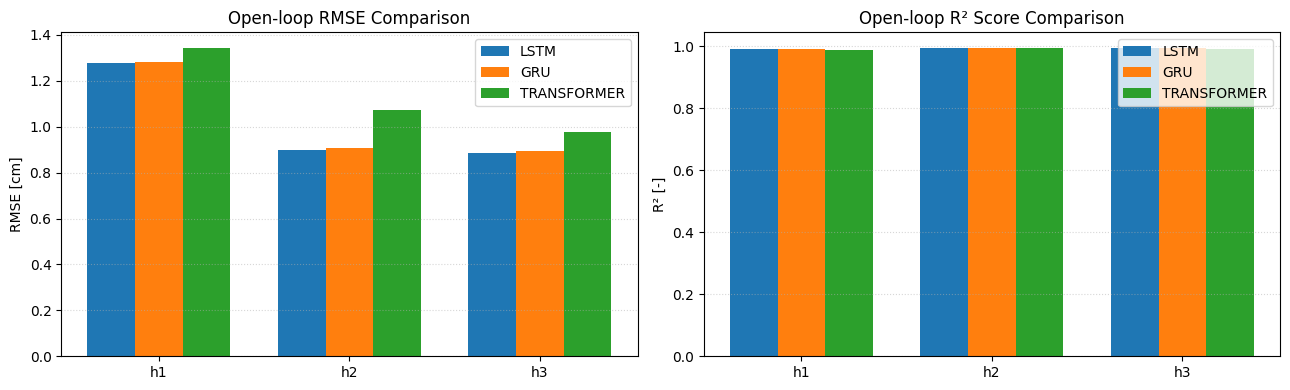

In [6]:
tank_names = ["h1", "h2", "h3"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(tank_names))
width = 0.25
for i, kind in enumerate(kinds):
    axes[0].bar(x + i * width, eval_results[kind]["rmse"], width, label=kind.upper())
    axes[1].bar(x + i * width, eval_results[kind]["r2"], width, label=kind.upper())
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(tank_names)
axes[0].set_title("Open-loop RMSE Comparison")
axes[0].set_ylabel("RMSE [cm]")
axes[0].legend()
axes[0].grid(True, axis='y', linestyle=":", alpha=0.5)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(tank_names)
axes[1].set_title("Open-loop R² Score Comparison")
axes[1].set_ylabel("R² [-]")
axes[1].legend()
axes[1].grid(True, axis='y', linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

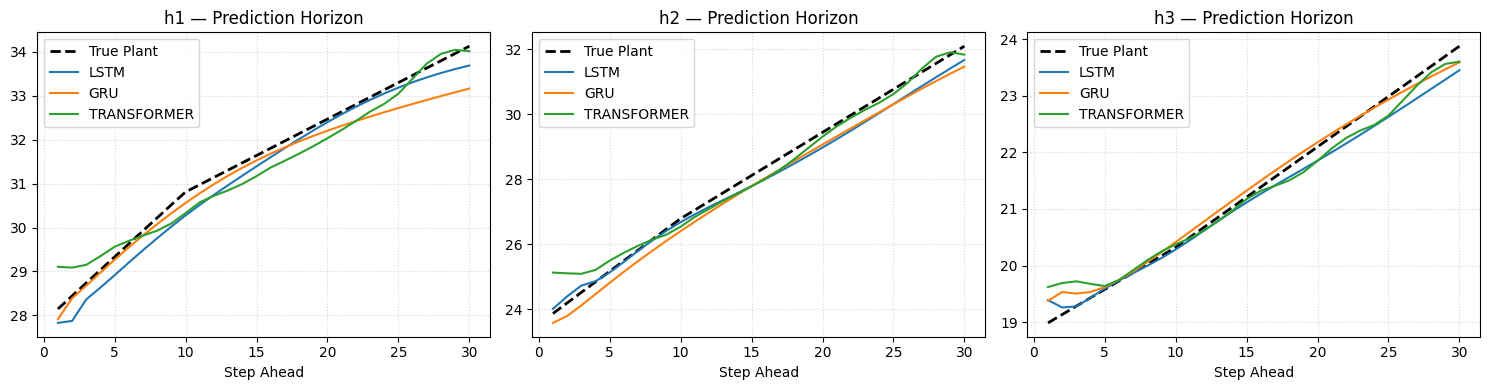

In [7]:
sample_batch = next(iter(test_loader))
u_hist_s, s0_s, u_fut_s, h_fut_s = [x[:1] for x in sample_batch]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_axis = np.arange(1, HORIZON + 1)
h_true_phys = h_fut_s[0].numpy() * norm.h_std + norm.h_mean

for tank_idx, name in enumerate(tank_names):
    axes[tank_idx].plot(t_axis, h_true_phys[:, tank_idx], "k--", label="True Plant", linewidth=2)
    for kind in kinds:
        with torch.no_grad():
            pred = models_trained[kind](u_hist_s.to(device), s0_s.to(device), u_fut_s.to(device))
        pred_phys = pred[0].cpu().numpy() * norm.h_std + norm.h_mean
        axes[tank_idx].plot(t_axis, pred_phys[:, tank_idx], label=kind.upper())
    axes[tank_idx].set_title(f"{name} — Prediction Horizon")
    axes[tank_idx].set_xlabel("Step Ahead")
    axes[tank_idx].legend()
    axes[tank_idx].grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Python ground-truth plant (for closed-loop testing)

In [8]:
# True plant equations and physical dimensions for closed-loop testing
PARAMS = dict(
    Sp=1.267, a=25.0, b=34.5, c=10.0, w=3.5, g=981.0, Hmax=35.0, R=36.4,
    C1=0.5838, C2=0.333, C3=0.333, C4=0.0,
    alpha1=0.4791, alpha2=0.4605, alpha3=0.4815,
    alpha4=0.5, alpha5=0.4581, alpha6=0.4831,
)

def tank_rhs(t, h, u, p=PARAMS):
    h1, h2, h3 = np.clip(h, 0.0, None)
    A1 = p["a"] * p["w"]
    A2 = p["c"] * p["w"] + (h2 / p["Hmax"]) * p["b"] * p["w"]
    A3 = p["w"] * np.sqrt(max(p["R"] ** 2 - (p["R"] - h3) ** 2, 1e-6))
    u1, u2, u3 = u
    f1 = p["C1"] * p["Sp"] * (2 * p["g"] * h1) ** p["alpha1"]
    f4 = p["C4"] * p["Sp"] * (2 * p["g"] * h1) ** p["alpha4"]
    f2 = u2 * p["Sp"] * (2 * p["g"] * h2) ** p["alpha2"]
    f5 = p["C2"] * p["Sp"] * (2 * p["g"] * h2) ** p["alpha5"]
    f3 = u3 * p["Sp"] * (2 * p["g"] * h3) ** p["alpha3"]
    f6 = p["C3"] * p["Sp"] * (2 * p["g"] * h3) ** p["alpha6"]
    dh1 = (u1 - f1 - f4) / A1
    dh2 = (f1 + f4 - f2 - f5) / A2
    dh3 = (f2 + f5 - f3 - f6) / A3
    return [dh1, dh2, dh3]


def step_plant(h0, u, dt, p=PARAMS):
    sol = solve_ivp(tank_rhs, [0, dt], h0, args=(u, p), method="RK45", rtol=1e-6, atol=1e-8)
    return np.clip(sol.y[:, -1], 0.0, p["Hmax"])

## 7. NMPC controller (SLSQP + PyTorch autograd)

In [9]:
class TankSurrogate:
    def __init__(self, ckpt_path, device="cpu"):
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(ckpt_path, map_location=self.device, weights_only=False)

        self.model = build_model(ckpt["kind"]).to(self.device)
        self.model.load_state_dict(ckpt["state_dict"])

        # LSTMs/GRUs need .train() for cuDNN autograd history; Transformers stay in .eval()
        self.kind = ckpt["kind"].lower()
        if self.kind in ["lstm", "gru"]:
            self.model.train()
        else:
            self.model.eval()

        # Freeze weights permanently
        for p in self.model.parameters():
            p.requires_grad_(False)

        self.norm = ckpt["norm"]
        self.hist_len = ckpt["hist_len"]
        self.horizon = ckpt["horizon"]
        self.u_mean = torch.tensor(self.norm.u_mean, dtype=torch.float32, device=self.device)
        self.u_std = torch.tensor(self.norm.u_std, dtype=torch.float32, device=self.device)
        self.h_mean = torch.tensor(self.norm.h_mean, dtype=torch.float32, device=self.device)
        self.h_std = torch.tensor(self.norm.h_std, dtype=torch.float32, device=self.device)

    def predict(self, u_hist_phys, s0_phys, u_fut_phys):
        u_hist_phys = u_hist_phys.to(self.device)
        s0_phys = s0_phys.to(self.device)
        u_fut_phys = u_fut_phys.to(self.device)

        u_hist_n = (u_hist_phys - self.u_mean) / self.u_std
        s0_n = (s0_phys - self.h_mean) / self.h_std
        u_fut_n = (u_fut_phys - self.u_mean) / self.u_std
        h_pred_n = self.model(u_hist_n.unsqueeze(0), s0_n.unsqueeze(0), u_fut_n.unsqueeze(0))
        return h_pred_n.squeeze(0) * self.h_std + self.h_mean


class TankNMPC:
    def __init__(self, surrogate, Q=(1.0, 1.0, 1.0), w_du=(0.05, 5.0, 5.0),
                 u_bounds=((20, 220), (0.05, 0.95), (0.05, 0.95)),
                 du_max=(30.0, 0.15, 0.15)):
        self.sur = surrogate
        self.Np = surrogate.horizon
        self.Q = torch.tensor(Q, dtype=torch.float32)
        self.w_du = torch.tensor(w_du, dtype=torch.float32)
        self.u_bounds = u_bounds
        self.du_max = np.array(du_max)
        self.last_u_opt = None  # FIX: stored so we can warm-start the next solve()

    def _cost_and_grad(self, u_flat, u_hist_phys, s0_phys, h_set, u_prev, bias):
        # PyTorch requires float32 for model inference
        u_t = torch.tensor(u_flat.reshape(self.Np, 3), dtype=torch.float32, device=self.sur.device, requires_grad=True)
        h_pred = self.sur.predict(u_hist_phys, s0_phys, u_t)

        # FIX: bias correction is applied to the OUTPUT prediction, not to
        # the state fed into the model. s0_phys is always the true measured
        # state now (see closed_loop_test_dynamic). Injecting bias into the
        # input state instead of the output created a runaway positive
        # feedback loop between model error and controller action.
        bias_t = torch.tensor(bias, dtype=torch.float32, device=self.sur.device)
        h_pred_corrected = h_pred + bias_t

        h_set_dev = h_set.to(self.sur.device)
        track_cost = torch.sum(self.Q.to(self.sur.device) * (h_pred_corrected - h_set_dev) ** 2)

        u_prev_t = torch.tensor(u_prev, dtype=torch.float32, device=self.sur.device)
        du = torch.cat([(u_t[0:1] - u_prev_t), u_t[1:] - u_t[:-1]], dim=0)
        move_cost = torch.sum(self.w_du.to(self.sur.device) * du ** 2)

        cost = track_cost + move_cost
        cost.backward()

        # CRITICAL FIX: Cast gradient from float32 back to float64 for SLSQP
        grad = u_t.grad.cpu().numpy().reshape(-1).astype(np.float64)
        return float(cost.item()), grad

    def solve(self, u_hist_phys, s0_phys, h_set, u_prev, bias=None, u_guess=None):
        if bias is None:
            bias = np.zeros(3)

        if u_guess is None:
            if self.last_u_opt is not None:
                # FIX: warm-start from the previous receding-horizon solution,
                # shifted forward one step, instead of resetting to a flat
                # guess every call. Re-solving from scratch each step let
                # SLSQP land in a different local optimum step to step on the
                # non-convex neural cost surface, which is what was actually
                # producing the valve chattering.
                u_guess = np.vstack([self.last_u_opt[1:], self.last_u_opt[-1:]])
            else:
                u_guess = np.tile(u_prev, (self.Np, 1))

        # CRITICAL FIX: Ensure optimization vector starts as float64
        x0 = u_guess.reshape(-1).astype(np.float64)

        bounds = []
        for k in range(self.Np):
            bounds.extend(self.u_bounds)

        def fun(x):
            return self._cost_and_grad(x, u_hist_phys, s0_phys, h_set, u_prev, bias)

        res = minimize(fun, x0, jac=True, method="SLSQP", bounds=bounds,
                        options={"maxiter": 100, "ftol": 1e-8})
        u_opt = self.apply_rate_limit(res.x.reshape(self.Np, 3), u_prev)
        self.last_u_opt = u_opt.copy()
        return u_opt

    def apply_rate_limit(self, u_seq, u_prev):
        u_seq = u_seq.copy()
        prev = u_prev.copy()
        for k in range(u_seq.shape[0]):
            delta = np.clip(u_seq[k] - prev, -self.du_max, self.du_max)
            u_seq[k] = prev + delta
            prev = u_seq[k]
        return u_seq


## 8. Closed-loop results

In [10]:
def closed_loop_test_dynamic(ckpt_path, sim_steps=400, dt=1.0, h0=None):
    sur = TankSurrogate(ckpt_path, device=device)
    ctrl = TankNMPC(sur)
    L, Np = sur.hist_len, sur.horizon

    if h0 is None:
        h0 = np.array([14.29, 13.51, 16.06])
    h = h0.copy()
    u_prev = np.array([100.0, 0.4, 0.2])
    u_hist_buf = np.tile(u_prev, (L, 1))

    bias = np.zeros(3)
    log_h, log_u, log_t = [h.copy()], [], [0.0]
    log_setpoint = []

    # Dynamic copy of simulation plant properties
    actual_plant_params = PARAMS.copy()

    for step in range(sim_steps):
        t_current = step * dt

        # 1. DYNAMIC SETPOINTS (Tracking Challenge)
        if t_current < 120.0:
            h_set_target = np.array([14.29, 13.51, 16.06])  # Nominal state
        elif t_current < 260.0:
            h_set_target = np.array([18.0, 15.0, 22.0])     # Step levels up
        else:
            h_set_target = np.array([10.0, 10.0, 12.0])     # Step levels down

        log_setpoint.append(h_set_target.copy())
        h_set_tensor = torch.tensor(np.tile(h_set_target, (Np, 1)), dtype=torch.float32)

        # 2. INJECT UNMEASURED LEAK (Disturbance Rejection Challenge at t = 200s)
        if t_current >= 200.0:
            actual_plant_params["C4"] = 0.35  # Opening unmeasured drain leak in Tank 1
        else:
            actual_plant_params["C4"] = 0.0

        # 3. CONTROLLER EVALUATION
        u_hist_t = torch.tensor(u_hist_buf, dtype=torch.float32)
        # FIX: s0 is always the TRUE measured state. Bias correction now
        # happens on the model's output prediction inside ctrl.solve(),
        # not by distorting the state we tell the model we're starting from.
        s0_t = torch.tensor(h, dtype=torch.float32)
        u_opt = ctrl.solve(u_hist_t, s0_t, h_set_tensor, u_prev, bias=bias)
        u_apply = u_opt[0]

        # 4. STEP THE REAL PHYSICS PLANT
        h_next = step_plant(h, u_apply, dt, p=actual_plant_params)

        # 5. ERROR OBSERVER (State correction vector - surrogate assumes C4=0)
        with torch.no_grad():
            u_opt_t = torch.tensor(u_opt, dtype=torch.float32)
            one_step_pred = sur.predict(u_hist_t, s0_t, u_opt_t)[0].cpu().numpy()

        bias = 0.7 * bias + 0.3 * (h_next - one_step_pred)

        # Update system memory
        u_hist_buf = np.vstack([u_hist_buf[1:], u_apply])
        u_prev, h = u_apply, h_next

        log_h.append(h.copy())
        log_u.append(u_apply.copy())
        log_t.append((step + 1) * dt)

    log_h, log_u = np.array(log_h), np.array(log_u)
    log_setpoint = np.array(log_setpoint)

    # Calculate tracking performance indices
    err = log_h[1:] - log_setpoint
    iae = np.sum(np.abs(err), axis=0) * dt
    ise = np.sum(err ** 2, axis=0) * dt

    return np.array(log_t), log_h, log_u, log_setpoint, iae, ise


In [11]:
closed_loop_results = {}

for kind in kinds:
    print(f"\n=== Simulating closed-loop NMPC using {kind.upper()} surrogate ===")
    t_log, h_log, u_log, setpoints_log, iae, ise = closed_loop_test_dynamic(
        os.path.join(OUT_DIR, f"{kind}_tank.pt"), sim_steps=400)
    closed_loop_results[kind] = {
        "t": t_log, "h": h_log, "u": u_log, "setpoints": setpoints_log, "iae": iae, "ise": ise
    }
    print(f"[{kind.upper()}] Integrated Absolute Error (IAE):", iae)
    print(f"[{kind.upper()}] Integrated Squared Error (ISE):", ise)


=== Simulating closed-loop NMPC using LSTM surrogate ===
[LSTM] Integrated Absolute Error (IAE): [698.77404739 354.22929819 572.50835756]
[LSTM] Integrated Squared Error (ISE): [2289.21150732  600.18843186 2052.75607919]

=== Simulating closed-loop NMPC using GRU surrogate ===
[GRU] Integrated Absolute Error (IAE): [572.00581984 410.79764151 578.67529078]
[GRU] Integrated Squared Error (ISE): [1633.90969236  766.22747044 2048.47437844]

=== Simulating closed-loop NMPC using TRANSFORMER surrogate ===
[TRANSFORMER] Integrated Absolute Error (IAE): [387.79165325 282.73051721 258.2153755 ]
[TRANSFORMER] Integrated Squared Error (ISE): [899.17035863 551.77690962 902.41320362]


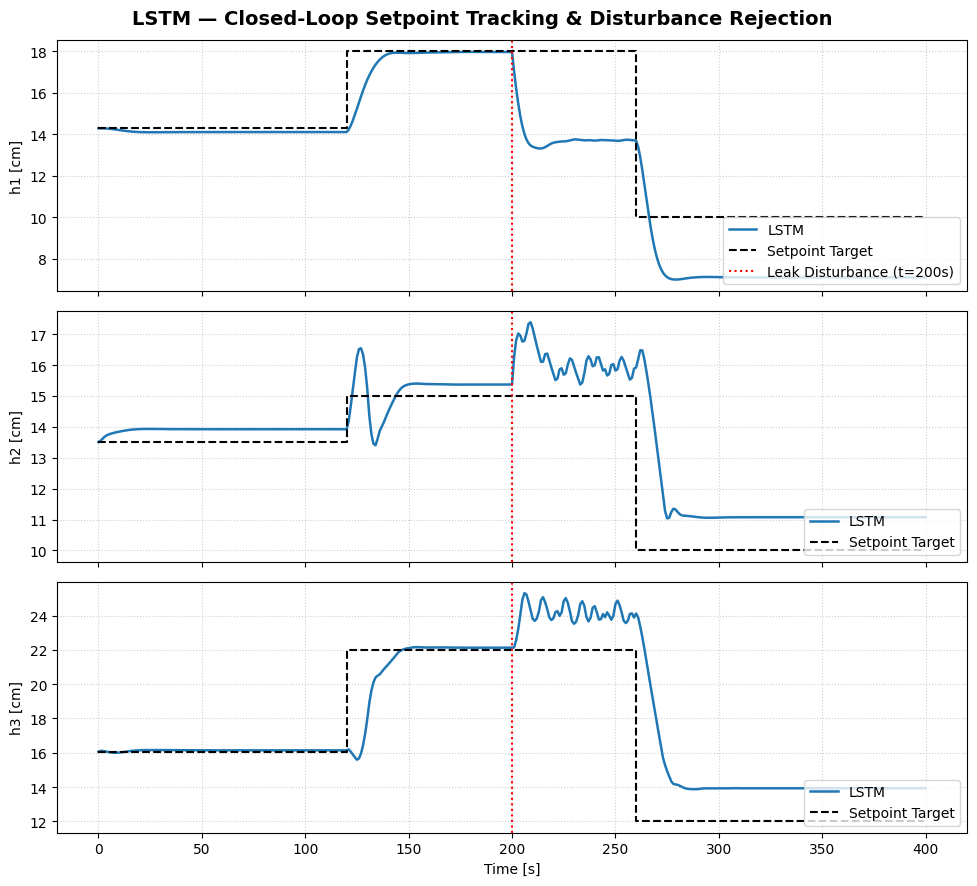

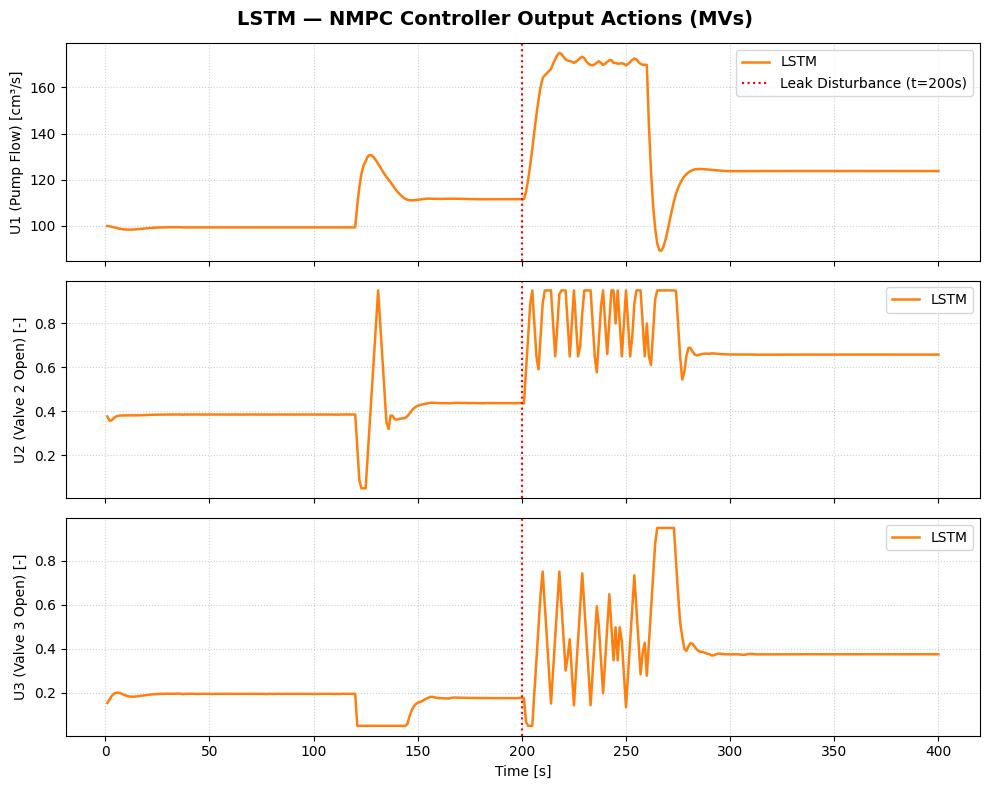

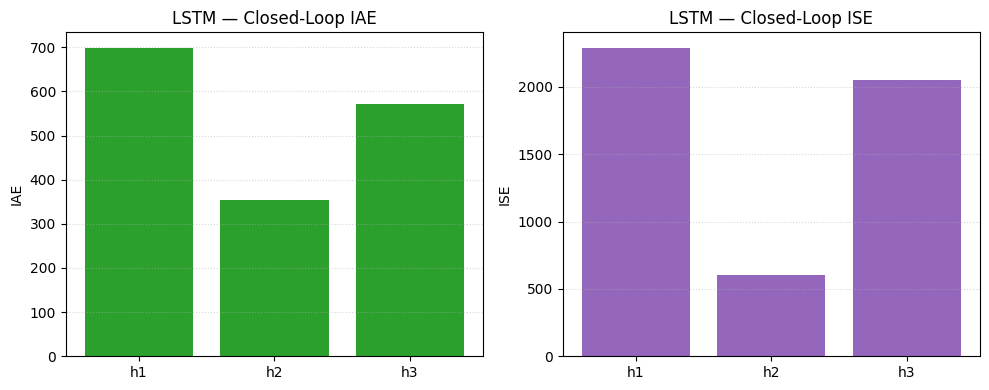

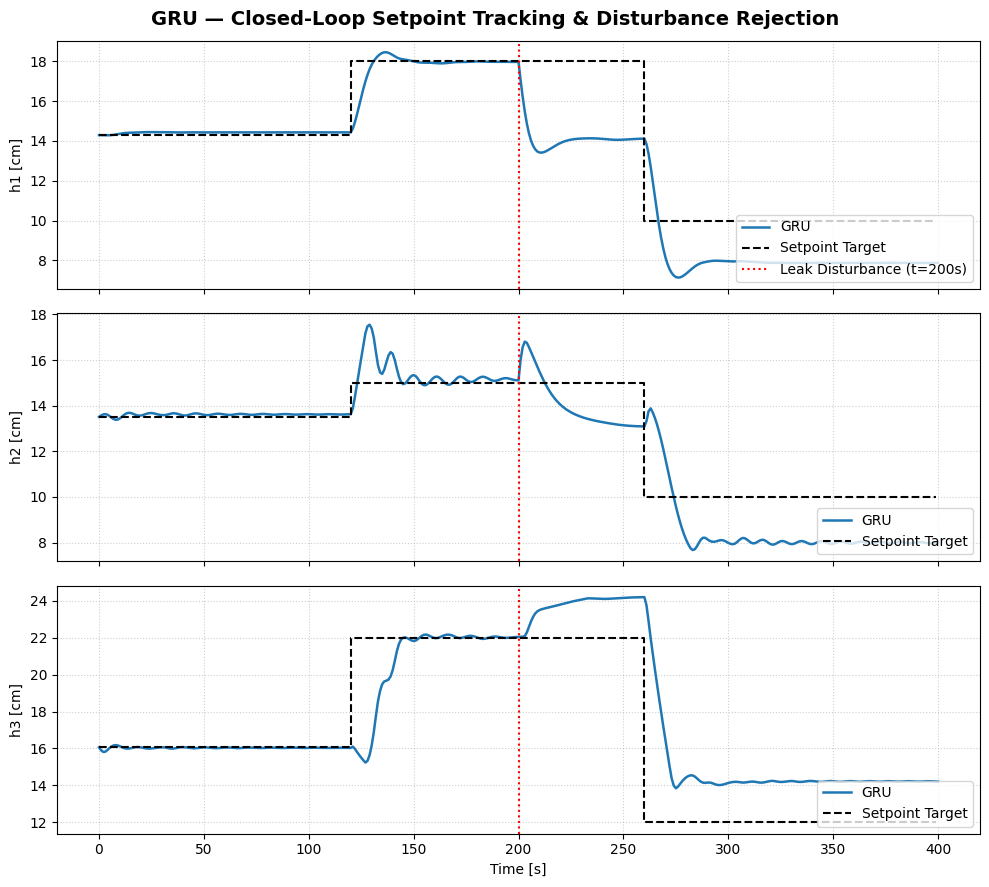

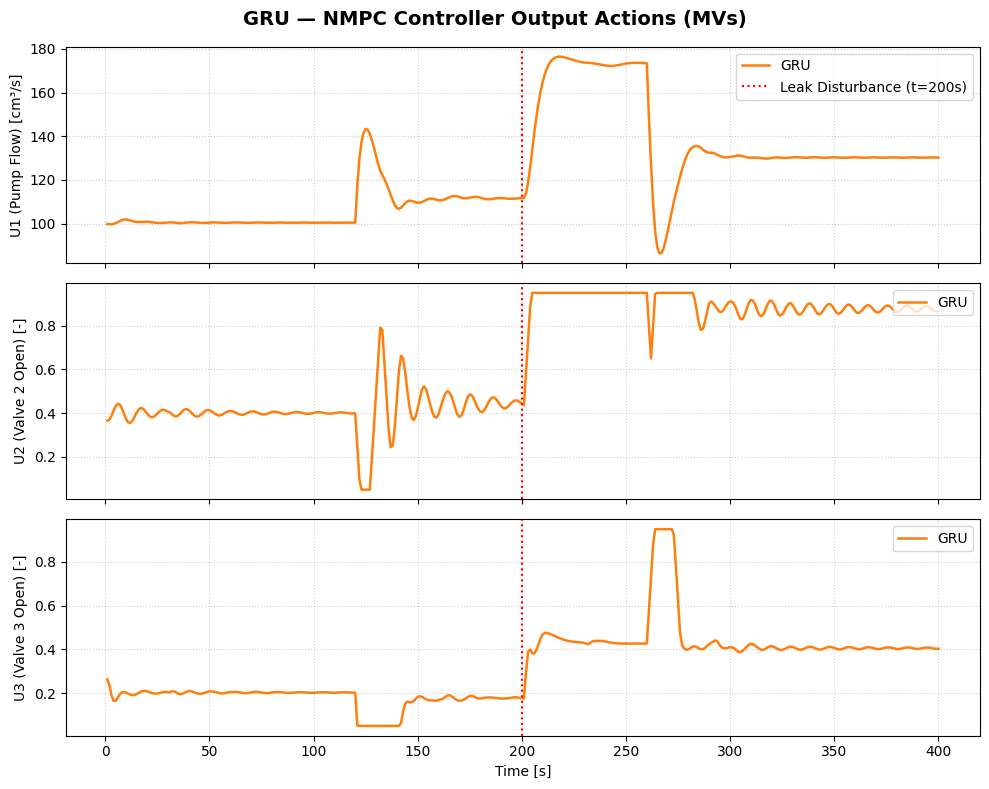

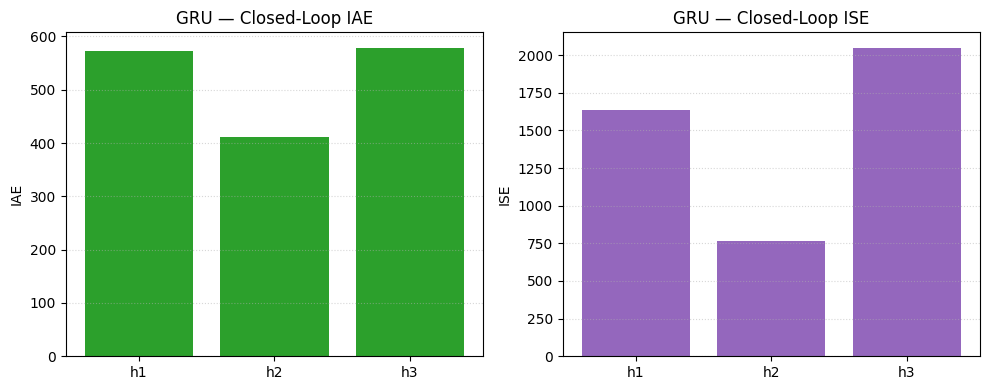

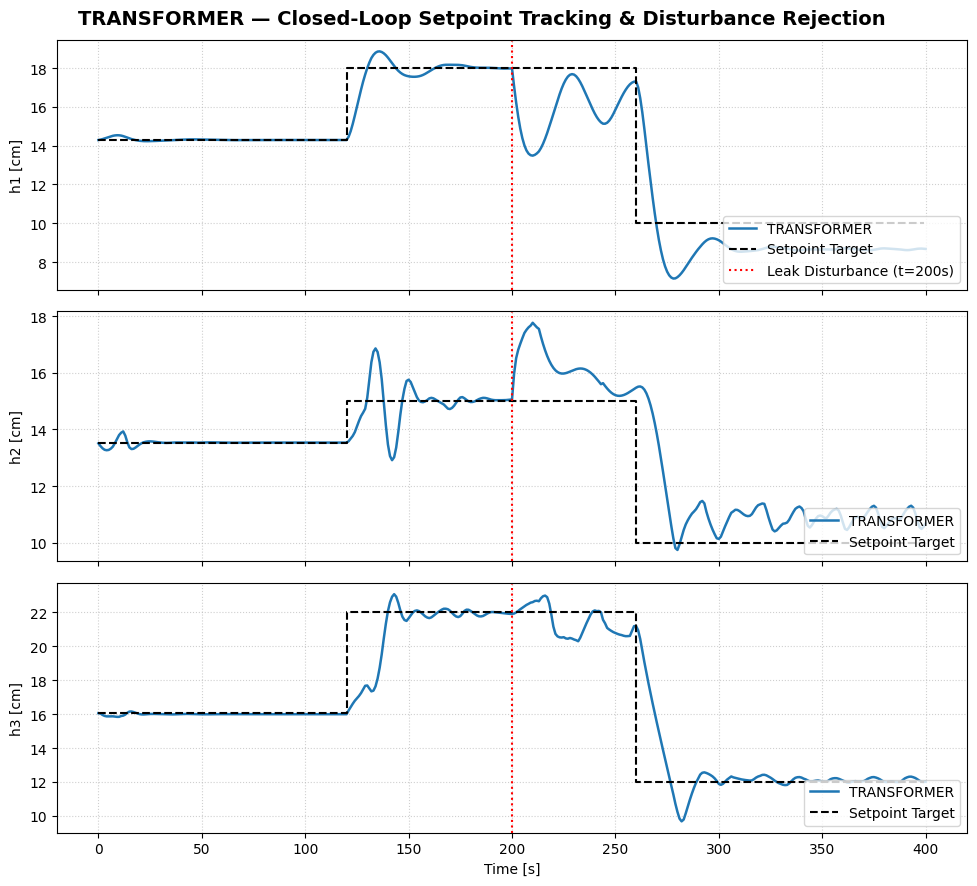

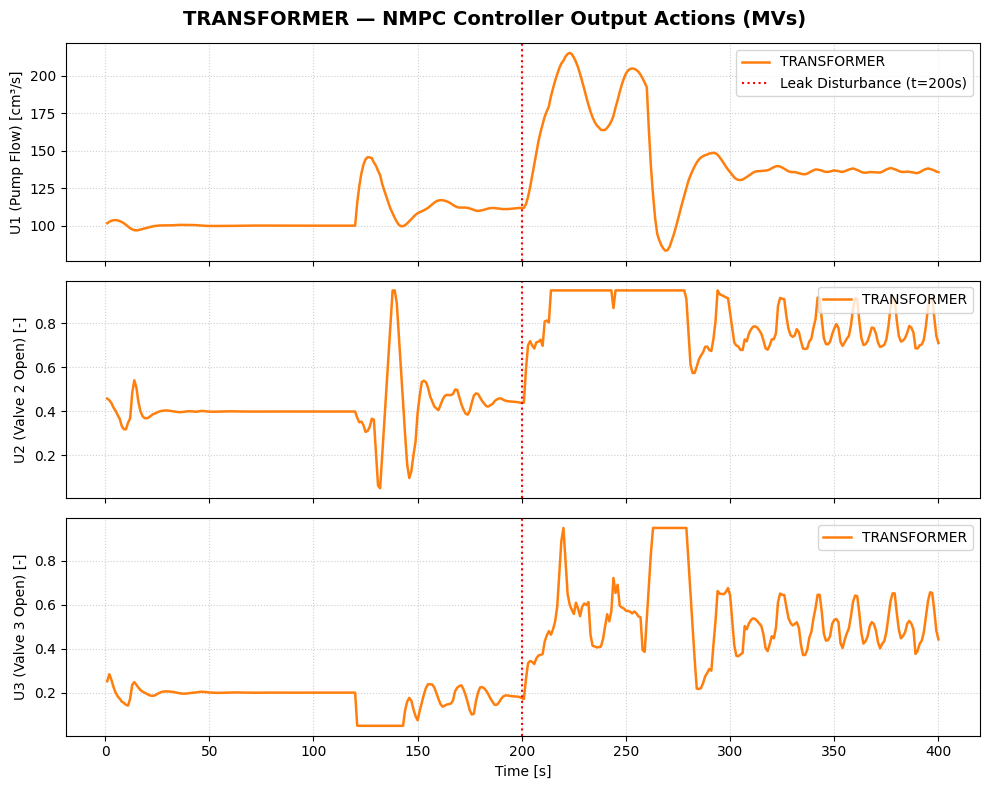

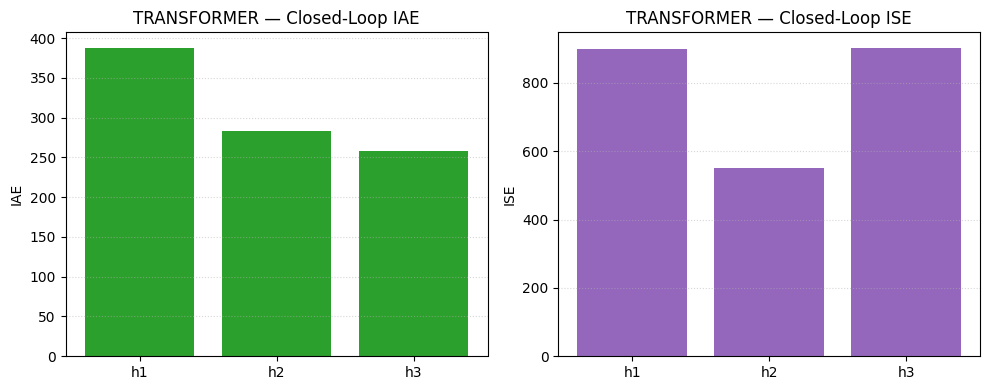


                           SUMMARY PERFORMANCE METRICS
Architecture    |   IAE h1   |   IAE h2   |   IAE h3   |   ISE h1   |   ISE h2   |   ISE h3  
--------------------------------------------------------------------------------
LSTM            |     698.77 |     354.23 |     572.51 |    2289.21 |     600.19 |    2052.76
GRU             |     572.01 |     410.80 |     578.68 |    1633.91 |     766.23 |    2048.47
TRANSFORMER     |     387.79 |     282.73 |     258.22 |     899.17 |     551.78 |     902.41


In [12]:
# ---- Per-architecture tracking + control action plots ----
for kind in kinds:
    res = closed_loop_results[kind]

    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    for tank_idx, name in enumerate(tank_names):
        axes[tank_idx].plot(res["t"], res["h"][:, tank_idx],
                             color="tab:blue", linewidth=1.8, label=kind.upper())
        axes[tank_idx].step(res["t"][:-1], res["setpoints"][:, tank_idx],
                             "k--", where="post", label="Setpoint Target", linewidth=1.5)
        axes[tank_idx].axvline(200.0, color="red", linestyle=":",
                                label="Leak Disturbance (t=200s)" if tank_idx == 0 else "")
        axes[tank_idx].set_ylabel(f"{name} [cm]")
        axes[tank_idx].legend(loc="lower right")
        axes[tank_idx].grid(True, linestyle=":", alpha=0.6)

    axes[-1].set_xlabel("Time [s]")
    plt.suptitle(f"{kind.upper()} — Closed-Loop Setpoint Tracking & Disturbance Rejection",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    u_labels = ["U1 (Pump Flow) [cm³/s]", "U2 (Valve 2 Open) [-]", "U3 (Valve 3 Open) [-]"]
    for u_idx in range(3):
        axes[u_idx].plot(res["t"][1:], res["u"][:, u_idx],
                          color="tab:orange", linewidth=1.8, label=kind.upper())
        axes[u_idx].axvline(200.0, color="red", linestyle=":",
                             label="Leak Disturbance (t=200s)" if u_idx == 0 else "")
        axes[u_idx].set_ylabel(u_labels[u_idx])
        axes[u_idx].legend(loc="upper right")
        axes[u_idx].grid(True, linestyle=":", alpha=0.6)

    axes[-1].set_xlabel("Time [s]")
    plt.suptitle(f"{kind.upper()} — NMPC Controller Output Actions (MVs)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(tank_names))
    axes[0].bar(x, res["iae"], color="tab:green")
    axes[0].set_xticks(x); axes[0].set_xticklabels(tank_names)
    axes[0].set_title(f"{kind.upper()} — Closed-Loop IAE")
    axes[0].set_ylabel("IAE")
    axes[0].grid(True, axis="y", linestyle=":", alpha=0.5)

    axes[1].bar(x, res["ise"], color="tab:purple")
    axes[1].set_xticks(x); axes[1].set_xticklabels(tank_names)
    axes[1].set_title(f"{kind.upper()} — Closed-Loop ISE")
    axes[1].set_ylabel("ISE")
    axes[1].grid(True, axis="y", linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()

# ---- Summary table stays as-is ----
print("\n" + "=" * 80)
print("                           SUMMARY PERFORMANCE METRICS")
print("=" * 80)
print(f"{'Architecture':<15} | {'IAE h1':^10} | {'IAE h2':^10} | {'IAE h3':^10} | {'ISE h1':^10} | {'ISE h2':^10} | {'ISE h3':^10}")
print("-" * 80)
for kind in kinds:
    iae = closed_loop_results[kind]["iae"]
    ise = closed_loop_results[kind]["ise"]
    print(f"{kind.upper():<15} | {iae[0]:10.2f} | {iae[1]:10.2f} | {iae[2]:10.2f} | {ise[0]:10.2f} | {ise[1]:10.2f} | {ise[2]:10.2f}")
print("=" * 80)